# 32 — Tamper material and neutron penalty

The tamper is primarily momentum mass. This workbook asks the narrower
material-economy question: what fraction of the useful 2.2-MeV
Constantine neutrons and 14.1-MeV DT neutrons suffer a nonelastic event
in the present 4:1 tamper mass column?

`total - elastic` is deliberately pessimistic: capture, inelastic
scattering, and neutron-multiplying reactions are all scored as loss.
The straight radial path is optimistic about path length. These two
choices bracket rather than replace transport.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

repo_root = Path.cwd()
while repo_root.name != 'CNO' and repo_root != repo_root.parent:
    repo_root = repo_root.parent
source_root = repo_root / 'analysis' / 'src'
if str(source_root) not in sys.path:
    sys.path.insert(0, str(source_root))
result_root = repo_root / 'analysis' / 'results' / 'roman-workbooks'
result_root.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 40)
pd.set_option('display.precision', 6)

from cno_sweep import (
    load_builtin_neutron_cross_sections,
    mixture_nonelastic_mass_attenuation_m2_kg,
    nonelastic_mass_attenuation_m2_kg,
    roman_phase_one_closure_target_sets,
    straight_path_nonelastic_survival,
)

xs = load_builtin_neutron_cross_sections()
targets = roman_phase_one_closure_target_sets()
natural_pb = {'pb204': 0.014, 'pb206': 0.241, 'pb207': 0.221, 'pb208': 0.524}
print(xs.metadata)

{'library': 'ENDF/B-VIII.0 neutron reaction sublibrary', 'source_url': 'https://www.nndc.bnl.gov/endf-b8.0/zips/ENDF-B-VIII.0_neutrons.zip', 'archive_md5': '90c1b1a6653a148f17cbf3c5d1171859', 'units': {'energy': 'eV', 'cross_section': 'barn'}}


## Data qualification

The light-nuclide and fast lead data come from the checksum-pinned
ENDF/B-VIII.0 neutron archive. Pb-208 below the resolved-resonance limit
uses NNDC's resonance-reconstructed 293.15 K API arrays. The other lead
isotopes have not yet been reconstructed below their resonance ranges,
so natural lead is compared only at 2.2 and 14.1 MeV. That limitation is
visible rather than hidden.

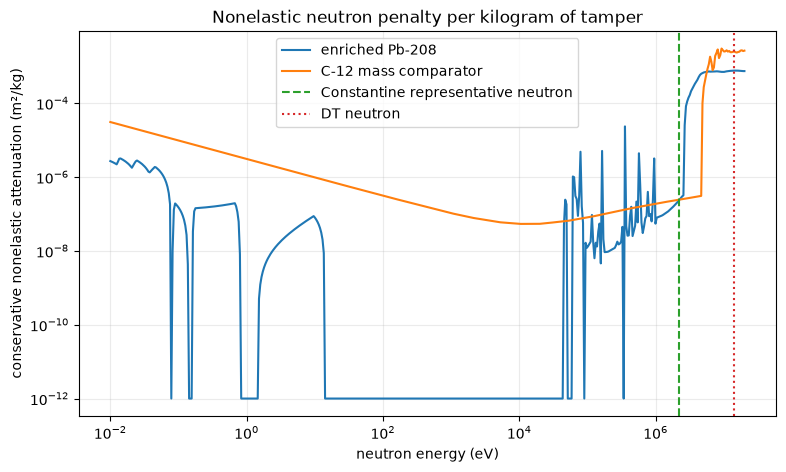

In [2]:
energies_eV = np.geomspace(1e-2, 2e7, 500)
pb208_mu = np.array([nonelastic_mass_attenuation_m2_kg(xs, 'pb208', e) for e in energies_eV])
c12_mu = np.array([nonelastic_mass_attenuation_m2_kg(xs, 'c12', e) for e in energies_eV])

fig, ax = plt.subplots(figsize=(9, 5))
ax.loglog(energies_eV, np.maximum(pb208_mu, 1e-12), label='enriched Pb-208')
ax.loglog(energies_eV, np.maximum(c12_mu, 1e-12), label='C-12 mass comparator')
ax.axvline(2.2e6, color='tab:green', ls='--', label='Constantine representative neutron')
ax.axvline(14.1e6, color='tab:red', ls=':', label='DT neutron')
ax.set(xlabel='neutron energy (eV)', ylabel='conservative nonelastic attenuation (m²/kg)',
       title='Nonelastic neutron penalty per kilogram of tamper')
ax.grid(True, which='both', alpha=.25)
ax.legend()
plt.show()

In [3]:
column_rows = []
for case_name, target_set in targets.items():
    target = target_set['constantine']
    column_rows.append({
        'case': case_name,
        'tamper/core mass ratio': target.driver_bracket.tamper_to_driver_mass_ratio,
        'Pb thickness (m)': target.tamper_thickness_m,
        'Pb radial column (kg/m²)': target.driver_bracket.tamper_density_kg_m3 * target.tamper_thickness_m,
    })
columns = pd.DataFrame(column_rows).set_index('case')
display(columns)

,tamper/core mass ratio,Pb thickness (m),Pb radial column (kg/m²)
case,,,
likely,4.0,0.000259,2.934352
conservative,4.0,0.015896,180.262255


In [4]:
materials = {
    'ideal transparent mass': None,
    'enriched Pb-208': {'pb208': 1.0},
    'natural Pb (fast region only)': natural_pb,
    'C-12 equal-mass comparator': {'c12': 1.0},
}
rows = []
for energy_mev in (2.2, 14.1):
    for material_name, composition in materials.items():
        mu = 0.0 if composition is None else mixture_nonelastic_mass_attenuation_m2_kg(
            xs, composition, energy_mev * 1e6
        )
        for case_name, row in columns.iterrows():
            rows.append({
                'neutron (MeV)': energy_mev,
                'tamper': material_name,
                'case': case_name,
                'nonelastic m²/kg': mu,
                'one-radial-path survival': straight_path_nonelastic_survival(
                    mu, row['Pb radial column (kg/m²)']
                ),
            })
attenuation = pd.DataFrame(rows)
display(attenuation.pivot_table(
    index=['neutron (MeV)', 'tamper'], columns='case',
    values='one-radial-path survival'
))

case                                         conservative    likely
neutron (MeV) tamper                                               
2.2           C-12 equal-mass comparator         0.999956  0.999999
              enriched Pb-208                    0.999958  0.999999
              ideal transparent mass             1.000000  1.000000
              natural Pb (fast region only)      0.961978  0.999369
14.1          C-12 equal-mass comparator         0.640084  0.992764
              enriched Pb-208                    0.871783  0.997769
              ideal transparent mass             1.000000  1.000000
              natural Pb (fast region only)      0.873699  0.997805

## Checkpoint result

- Pb-208 is exceptionally favorable for the approximately 2.2-MeV
  Constantine neutron: the current straight-path nonelastic survival is
  essentially unity in both target brackets.
- Natural lead is materially worse near 2.2 MeV because Pb-204/206/207
  have open inelastic channels. Enrichment is not a cosmetic detail.
- At 14.1 MeV the Pb-208 advantage disappears. All stable lead isotopes
  have substantial nonelastic channels; a thick conservative target can
  materially degrade DT-neutron recovery.
- C-12 is not a free replacement: it is much worse per kilogram at
  14.1 MeV and far less dense, so its geometry and momentum coupling
  differ.

This workbook supports Pb-208 as the baseline momentum material for
Constantine. It does **not** close activation, secondary-neutron
multiplicity, elastic backscatter, or mechanical survivability; those
require channel-resolved transport and the spherical driver history.

In [5]:
artifact = {
    'schema': 'roman-tamper-screen-v0.1',
    'natural_pb_atom_fractions': natural_pb,
    'columns': column_rows,
    'attenuation_rows': rows,
    'qualification': 'Pb208 uses reconstructed 293.15 K arrays; natural Pb is fast-region only',
}
path = result_root / '32-tamper-material-v0.1.json'
path.write_text(json.dumps(artifact, indent=2))
print('wrote', path.relative_to(repo_root))

wrote analysis/results/roman-workbooks/32-tamper-material-v0.1.json
